In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [3]:
ticker = 'I:SPX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2024-12-06", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

9906382it [03:45, 43899.98it/s]


In [4]:
ticker_hist

,Open,Close,high,low,volume,Datetime,transactions
0,4138.09,4138.09,4138.09,4138.09,None,2023-02-14 13:22:33,None
1,4138.17,4138.17,4138.17,4138.17,None,2023-02-14 13:22:34,None
2,4138.22,4138.22,4138.22,4138.22,None,2023-02-14 13:22:35,None
3,4138.24,4138.24,4138.24,4138.24,None,2023-02-14 13:22:36,None
4,4138.23,4138.23,4138.23,4138.23,None,2023-02-14 13:22:37,None
...,...,...,...,...,...,...,...
9900459,6089.72,6089.72,6089.72,6089.72,None,2024-12-06 15:59:56,None
9900460,6088.77,6088.77,6088.77,6088.77,None,2024-12-06 15:59:57,None
9900461,6088.26,6088.26,6088.26,6088.26,None,2024-12-06 15:59:58,None
9900462,6088.76,6088.76,6088.76,6088.76,None,2024-12-06 15:59:59,None


In [5]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()
    logReturns = ticker_hist_date['logOpen'].diff().dropna()

    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_29852/3392873665.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ticker_hist_date = ticker_hist_date.ffill()
457it [02:50,  2.69it/s]


In [6]:
times

,Time
0,09:30:01
1,09:30:02
2,09:30:03
3,09:30:04
4,09:30:05
...,...
23395,15:59:56
23396,15:59:57
23397,15:59:58
23398,15:59:59


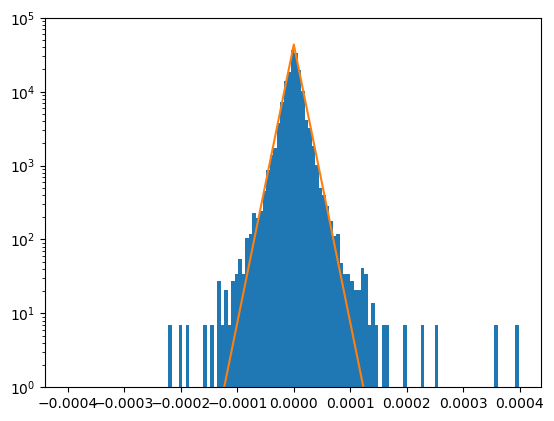

In [7]:
plt.hist(logReturns, bins = 100, density = True)

plt.plot(
    np.arange(-0.0004, 0.0004, 0.00001),
    1 / (2*b) * np.exp(
        - np.abs(
            np.arange(-0.0004, 0.0004, 0.00001) - a
        )/(b)
    )
)
plt.ylim(10**0, 10**5)
plt.yscale('log')
plt.show()

In [8]:
b

np.float64(1.1530996388428399e-05)

In [9]:
mu = np.mean(logReturns)

In [10]:
sigma = np.std(logReturns)

In [11]:
np.mean((logReturns - mu)**3)/sigma**3

np.float64(0.9860654658501966)

In [12]:
np.mean((logReturns - mu)**4)/sigma**4

np.float64(33.38879652715238)

In [13]:
autocorrs = []
for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()

    logReturns = ticker_hist_date['logOpen'].diff().dropna()

    autocorrs.append(scipy.stats.pearsonr(logReturns[1:], logReturns[:-1]).statistic)

    

0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_29852/2725378277.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ticker_hist_date = ticker_hist_date.ffill()
457it [02:51,  2.67it/s]


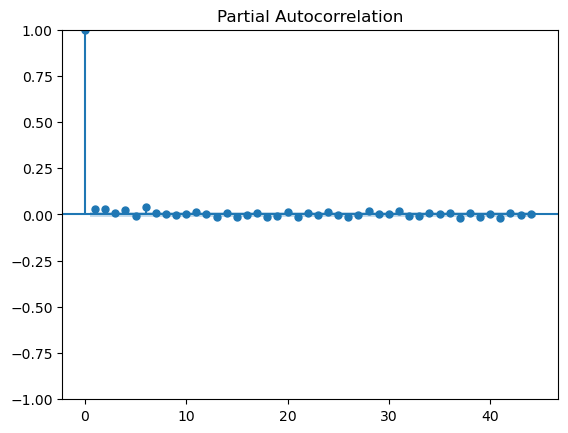

In [14]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    logReturns
)
plt.show()

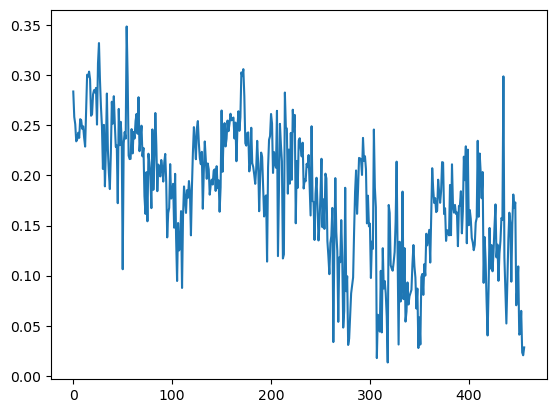

In [15]:
plt.plot(autocorrs)

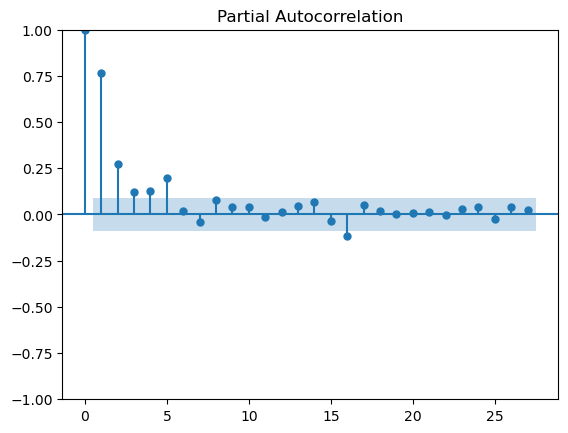

In [16]:
statsmodels.graphics.tsaplots.plot_pacf(
    np.asarray(autocorrs)
)
plt.title("Partial Autocorrelation")
plt.show()

(0.0, 0.4)

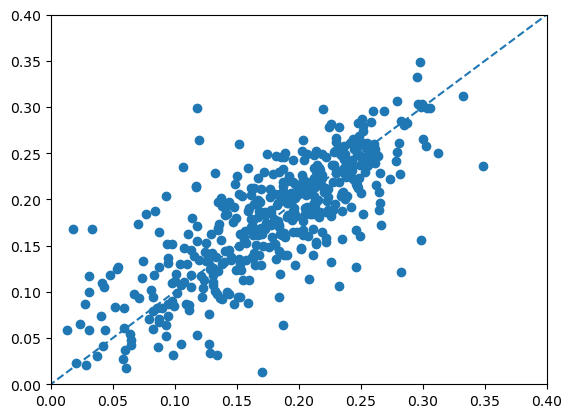

In [17]:
plt.scatter(np.asarray(autocorrs)[1:], np.asarray(autocorrs)[:-1])
plt.plot([-1,1],[-1,1], '--')
plt.xlim([0, 0.4])
plt.ylim([0, 0.4])


In [18]:
ab_params_df = pd.DataFrame(ab_params)
ab_params_df = ab_params_df.dropna()

In [19]:
ab_params_df

,a,b
2023-02-14,0.0,0.000019
2023-02-15,0.0,0.000018
2023-02-16,0.0,0.000021
2023-02-17,0.0,0.000019
2023-02-21,0.0,0.000018
...,...,...
2024-12-02,0.0,0.000012
2024-12-03,0.0,0.000011
2024-12-04,0.0,0.000011
2024-12-05,0.0,0.000011


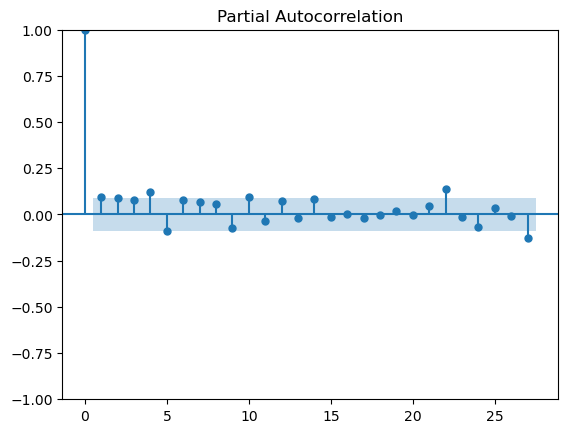

In [20]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

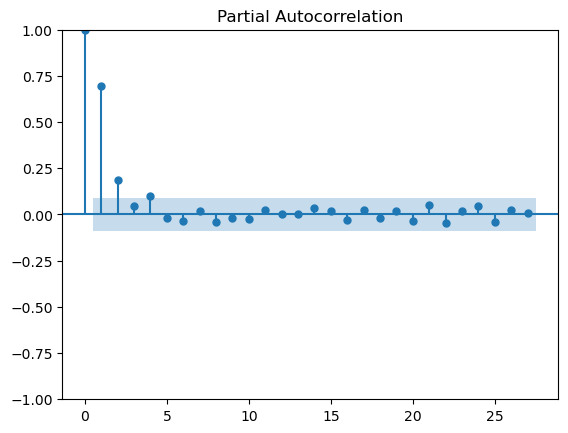

In [21]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [22]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.09946317900567483), pvalue=np.float64(0.03372113996201583))

In [23]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.6966966509759939), pvalue=np.float64(1.719511100603992e-67))

In [24]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.5367795547832644), pvalue=np.float64(2.5702074431016207e-35))

In [25]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.08022751747030693), pvalue=np.float64(0.08703532859762486))

In [26]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [27]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.4854482044351722
0.08327379225329234


In [28]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [29]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5072584526629133
0.08849246877116845


In [30]:
r_b.coef_

array([ 0.72508758,  0.1949694 , -0.46401606,  0.56051092])

In [31]:
lr_b.coef_

array([0.10401282, 0.69597192])

In [32]:
lr_a.coef_

array([0.05893728, 0.02100483])

In [33]:
r_a.coef_

array([0.06335754, 0.00335548, 0.04488145, 0.01837095])

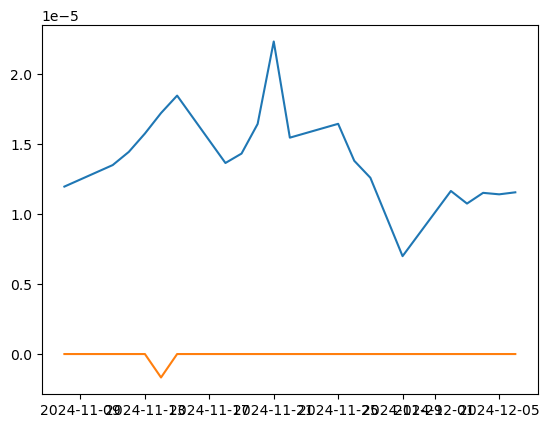

In [34]:
plt.plot(ab_params_df['b'][-20:])
plt.plot(ab_params_df['a'][-20:])


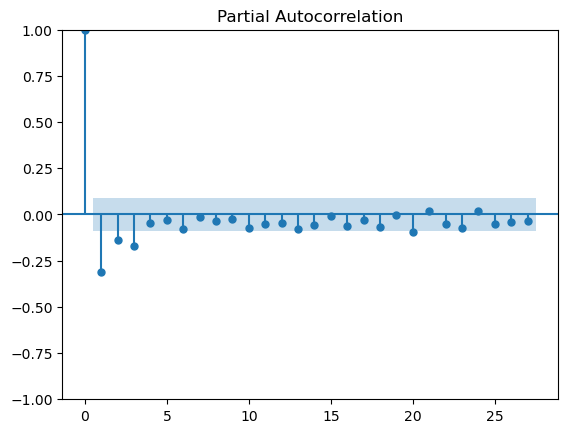

In [35]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b'].diff()[1:]
)
plt.show()

(332.0, 453.0)

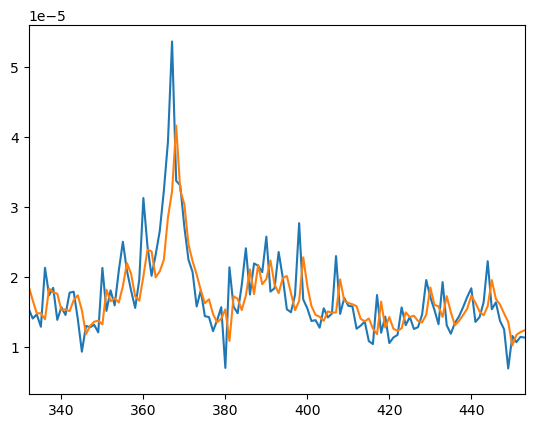

In [36]:
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True))
plt.plot(r_b.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna()))

plt.xlim(332,453)

(332.0, 453.0)

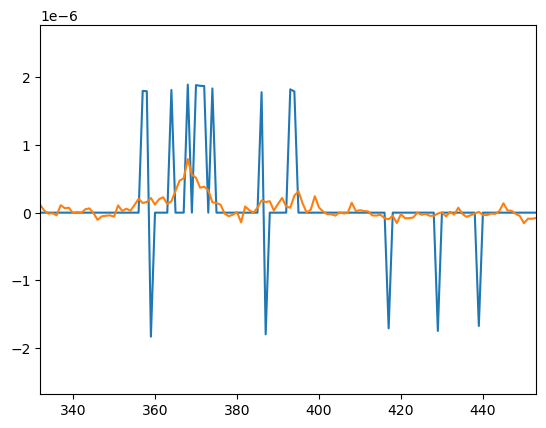

In [37]:
plt.plot(ab_params_df.dropna()['shifted_a_2'].reset_index(drop=True))
plt.plot(r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]))

plt.xlim(332,453)

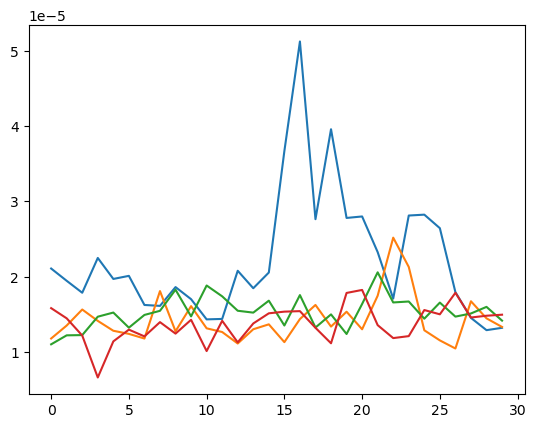

In [38]:
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[:30].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[30:60].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[60:90].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[90:120].reset_index(drop = True))


In [39]:
replicates = 100000

In [40]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [02:24<00:00, 691.27it/s]


In [41]:
len(ticker_hist_date)

23400

In [42]:
6.5*3600

23400.0

In [43]:
np.std(possible_final_returns)

np.float64(0.002711582318950456)

In [44]:
r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1]

np.float64(-7.582314548683973e-08)

In [45]:
r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1]

np.float64(1.2579071242317453e-05)

# declare spot ticker price

In [46]:
spot_spx_price = 6084.

In [47]:
upper_call = 5945.
lower_call = 5940.
upper_put = 5860.
lower_put = 5855.

In [48]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [49]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

6073.291813301811
16.468363980335454


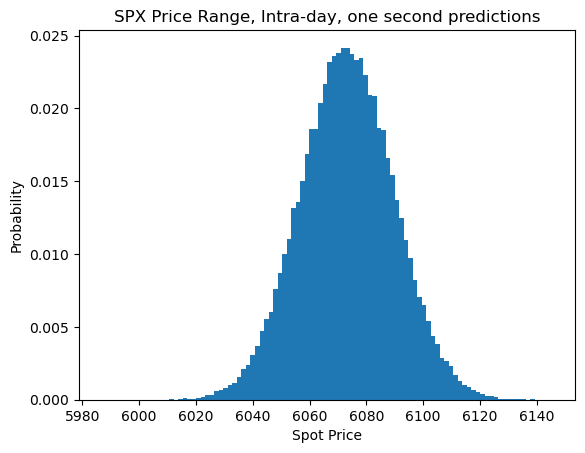

In [50]:
plt.hist(possible_final_prices, bins = 100, density = True)
plt.ylabel('Probability')
plt.xlabel('Spot Price')
plt.title('SPX Price Range, Intra-day, one second predictions')
#plt.savefig('end_price_distro_t2.pdf', bbox_inches = 'tight')
plt.show()

In [51]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

Text(0.5, 1.0, 'avg payout is -5.0')

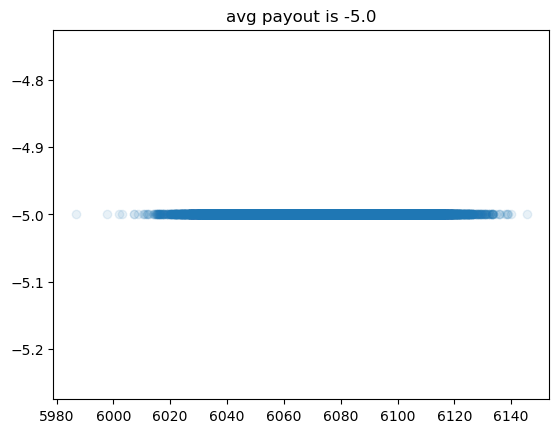

In [52]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

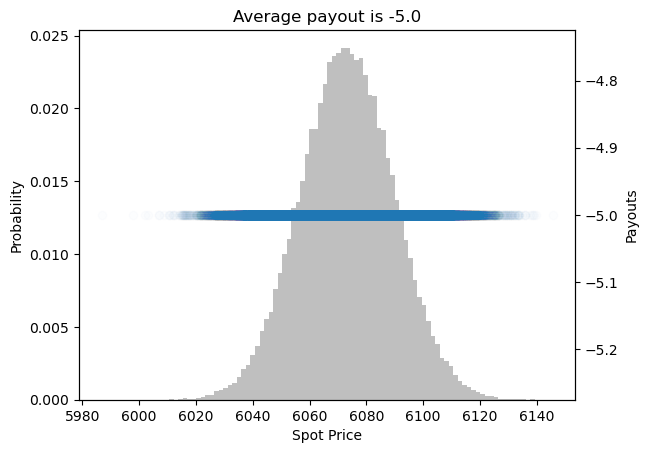

In [53]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
#plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [233]:
cost_of_trade = 0.7
max_loss = 5

In [234]:
p = (max_loss - cost_of_trade)/max_loss

In [235]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is -2.220446049250313e-16


In [236]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.6766428571428569
